# 1. Exploring CBS Speeches Sentiment
This notebook analyzes the output generated by the `auto_econ_sentiment` pipeline on the CBS central bank speeches dataset.

## 1.1 Imports and Setup
Load necessary libraries for the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
#%matplotlib inline

## 1.2 Load the Data
Load the `sentiment_all_results.csv` generated by the pipeline.

In [10]:
df = pd.read_csv('../data/sentiment/cb_speeches/sentiment_all_results.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')#.reset_index(drop=True)
df.head(2)

,id_text,URL,PDF,Title,Subtitle,date,Authorname,Role,Gender,CentralBank,...,hubert_sentiment_allwords,lm_sentiment_posneg,lm_sentiment_allwords,hiv_sentiment_posneg,hiv_sentiment_allwords,bn_sentiment_posneg_stem,bn_sentiment_allwords_stem,ap_sentiment_posneg_stem,ap_sentiment_allwords_stem,Country_ISO2
20755,247,https://fraser.stlouisfed.org/files/docs/histo...,https://fraser.stlouisfed.org/title/statements...,The Economic Outlook for 1986 : Remarks to the...,NaN,1986-01-06,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,...,1.005141,0.724324,0.973779,1.263158,1.020566,0.761905,0.992288,1.0,1.000000,US
18538,154,https://fraser.stlouisfed.org/files/docs/histo...,https://fraser.stlouisfed.org/title/statements...,"1986: What We Know, What We Don't Know, and Wh...",NaN,1986-01-08,Thomas C Melzer,Governor,Male,Federal Reserve Bank of St Louis,...,1.009288,0.328767,0.949432,0.800000,0.988648,0.956522,0.998968,1.6,1.006192,US


In [11]:

df.head().CentralBank.unique()

array(['Federal Reserve Bank of Atlanta',
       'Federal Reserve Bank of St Louis'], dtype=object)

# 2. Overview of Sentiment Results
Let's check the basic statistics of the sentiment scores computed across the different dictionaries by the pipeline.

In [12]:
# Extract sentiment columns
sentiment_cols = [col for col in df.columns if 'sentiment' in col]

df[sentiment_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
correa_sentiment_posneg,35487.0,1.015635,0.399729,0.000000,0.731707,0.979592,1.266667,2.000000
correa_sentiment_allwords,35487.0,0.999054,0.012207,0.915459,0.991943,0.999396,1.006601,1.069767
hubert_sentiment_posneg,35487.0,1.397080,0.419076,0.000000,1.125000,1.428571,1.692308,2.000000
hubert_sentiment_allwords,35487.0,1.005251,0.006656,0.945205,1.001302,1.004426,1.008351,1.073529
lm_sentiment_posneg,35487.0,0.957009,0.363895,0.000000,0.689076,0.907407,1.187970,2.000000
lm_sentiment_allwords,35487.0,0.995030,0.024575,0.849462,0.979249,0.994283,1.010753,1.113095
hiv_sentiment_posneg,35487.0,1.398617,0.311493,0.000000,1.194030,1.414141,1.628571,2.000000
hiv_sentiment_allwords,35487.0,1.028688,0.024713,0.885542,1.013151,1.027913,1.043326,1.189015
bn_sentiment_posneg_stem,35487.0,1.468363,0.369951,0.000000,1.230769,1.500000,1.745455,2.000000
bn_sentiment_allwords_stem,35487.0,1.008532,0.008225,0.933086,1.003663,1.007905,1.012739,1.076923


## 2.1 Sentiment Score Distributions
Visualizing the distribution of the different sentiment metrics.

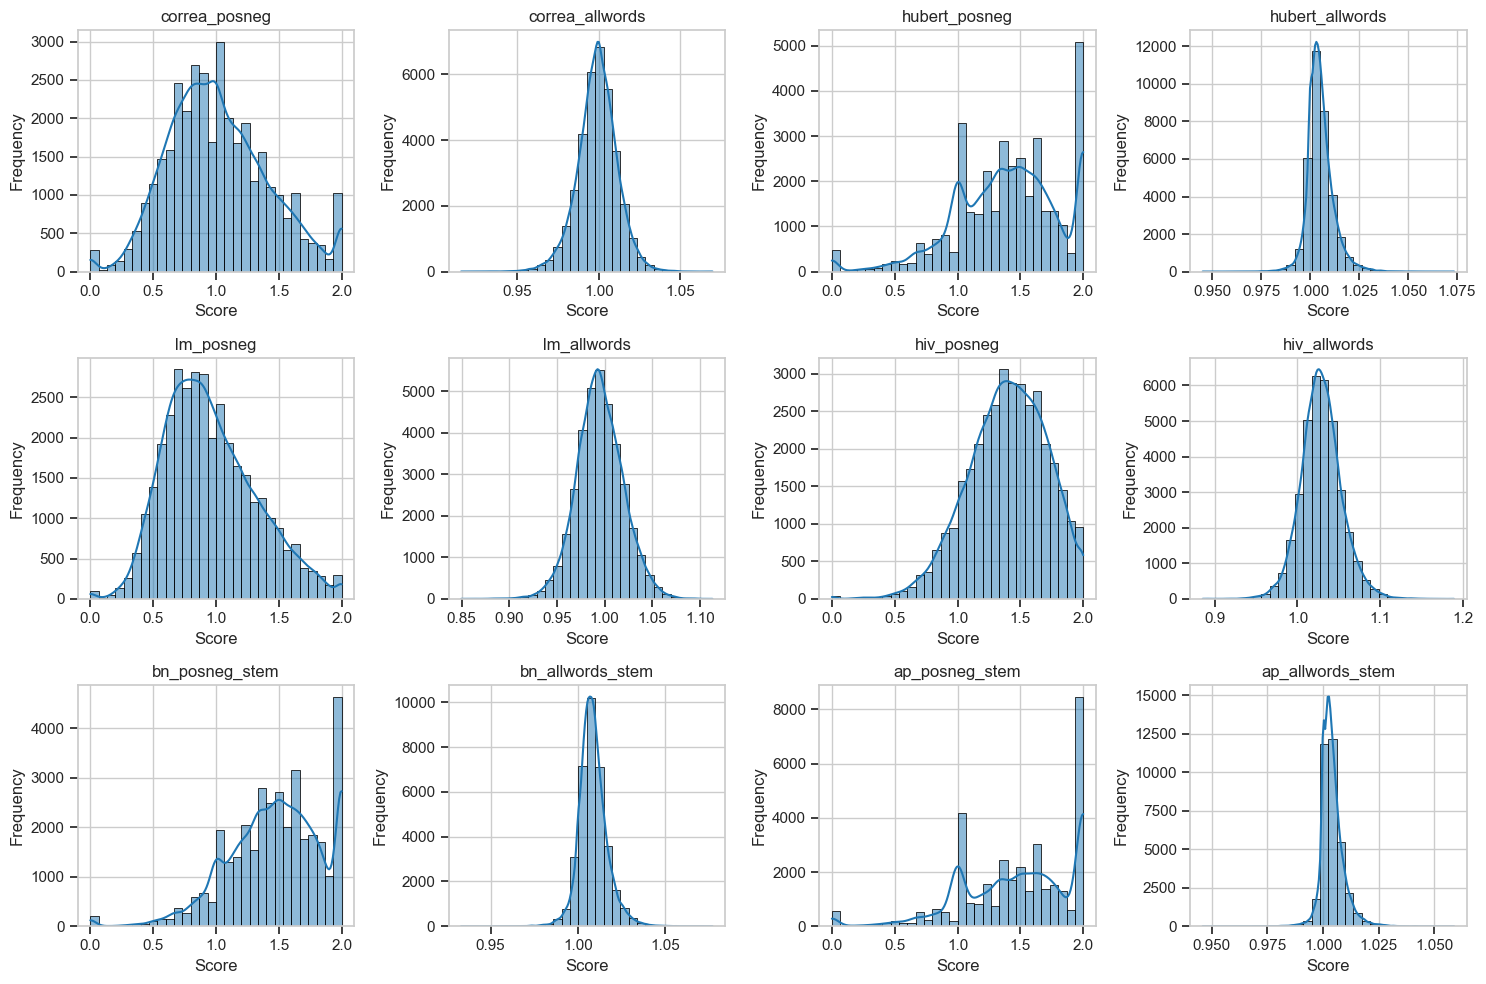

In [13]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(sentiment_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col.replace('_sentiment', ''))
    plt.xlabel('Score')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Time Series Analysis
How has the sentiment of Federal Reserve speeches evolved over time?

## 3.1 Monthly Aggregation
Since speeches happen irregularly, we aggregate the sentiment to a monthly frequency.

In [14]:
df.head(2)

,id_text,URL,PDF,Title,Subtitle,date,Authorname,Role,Gender,CentralBank,...,hubert_sentiment_allwords,lm_sentiment_posneg,lm_sentiment_allwords,hiv_sentiment_posneg,hiv_sentiment_allwords,bn_sentiment_posneg_stem,bn_sentiment_allwords_stem,ap_sentiment_posneg_stem,ap_sentiment_allwords_stem,Country_ISO2
20755,247,https://fraser.stlouisfed.org/files/docs/histo...,https://fraser.stlouisfed.org/title/statements...,The Economic Outlook for 1986 : Remarks to the...,NaN,1986-01-06,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,...,1.005141,0.724324,0.973779,1.263158,1.020566,0.761905,0.992288,1.0,1.000000,US
18538,154,https://fraser.stlouisfed.org/files/docs/histo...,https://fraser.stlouisfed.org/title/statements...,"1986: What We Know, What We Don't Know, and Wh...",NaN,1986-01-08,Thomas C Melzer,Governor,Male,Federal Reserve Bank of St Louis,...,1.009288,0.328767,0.949432,0.800000,0.988648,0.956522,0.998968,1.6,1.006192,US


In [15]:
df_time = df.set_index('date')

# Aggregate by month (mean)
monthly_sentiment = df_time[sentiment_cols].resample('ME').mean()
monthly_sentiment.head()

,correa_sentiment_posneg,correa_sentiment_allwords,hubert_sentiment_posneg,hubert_sentiment_allwords,lm_sentiment_posneg,lm_sentiment_allwords,hiv_sentiment_posneg,hiv_sentiment_allwords,bn_sentiment_posneg_stem,bn_sentiment_allwords_stem,ap_sentiment_posneg_stem,ap_sentiment_allwords_stem
date,,,,,,,,,,,,
1986-01-31,0.626068,0.985446,1.320546,1.004687,0.708600,0.977359,1.226858,1.012254,1.114055,1.000706,1.469271,1.003459
1986-02-28,0.691423,0.988066,1.375138,1.005769,0.727651,0.977271,1.260795,1.018730,1.191872,1.003416,1.577301,1.005053
1986-03-31,0.743188,0.991005,1.369075,1.004405,0.670139,0.976370,1.300125,1.021683,1.462514,1.008472,1.691783,1.004866
1986-04-30,0.647727,0.985457,1.400117,1.005683,0.706485,0.975626,1.189209,1.013733,1.322302,1.006583,1.701726,1.006460
1986-05-31,0.816187,0.988379,1.536381,1.007841,0.727220,0.976884,1.322943,1.027651,1.547107,1.010480,1.780006,1.005691


## 3.2 Plotting the Trends
Plotting the 6-month rolling average for a smoother view of the hawkish/dovish trends.

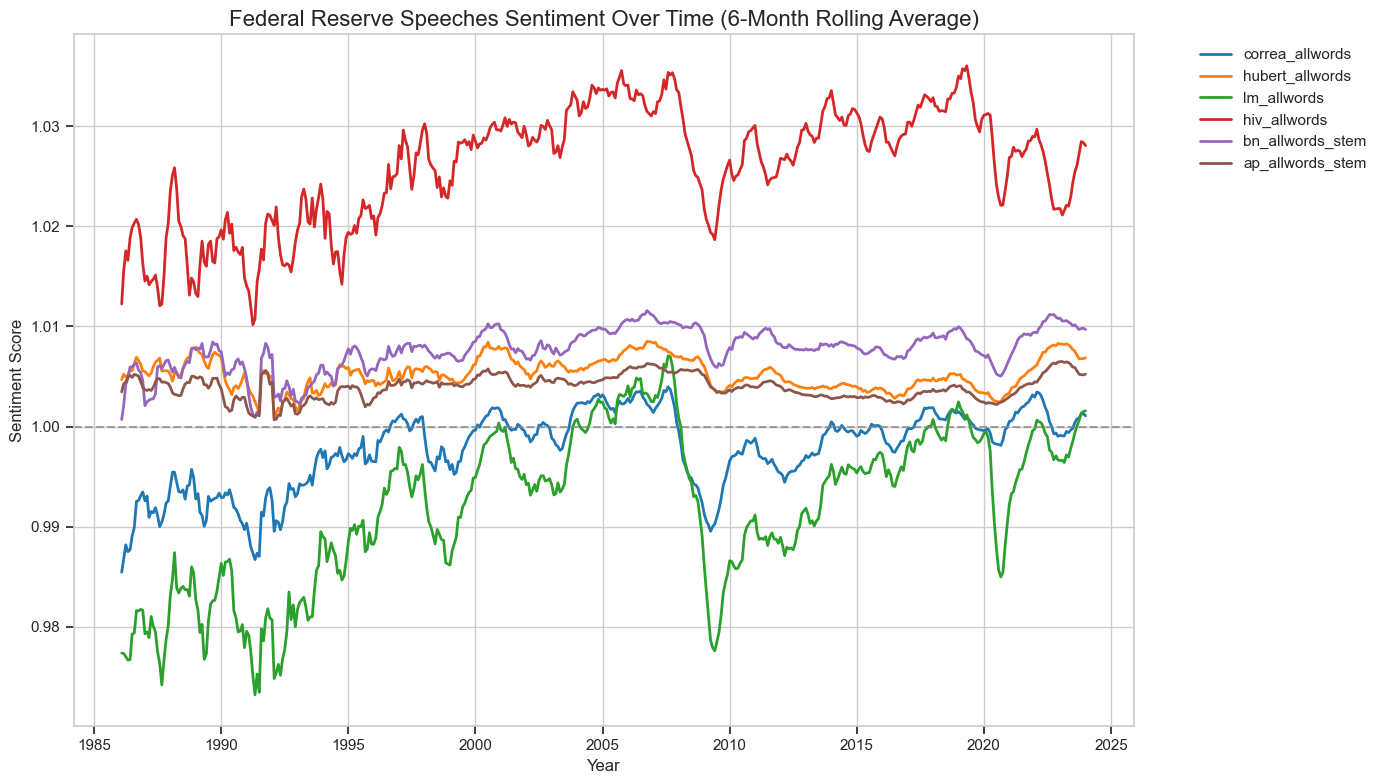

In [16]:
# Smooth the time series with a rolling average
rolling_sentiment = monthly_sentiment.rolling(window=6, min_periods=1).mean()

plt.figure(figsize=(14, 8))
# Let's plot the allwords methods as an example
plot_cols = [c for c in sentiment_cols if 'allwords' in c]

for col in plot_cols:
    plt.plot(rolling_sentiment.index, rolling_sentiment[col], label=col.replace('_sentiment', ''), linewidth=2)

plt.title('Federal Reserve Speeches Sentiment Over Time (6-Month Rolling Average)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sentiment Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()